In [16]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

[0.00070048 0.14736701]
[1.6232661  2.46257472 3.2267219  3.96702729 4.74348525]


C:\Users\Lucas\AppData\Local\Temp\ipykernel_1116\1678408724.py:28: RuntimeWarning: invalid value encountered in log10
  return np.log10(k*x**p)
C:\Users\Lucas\AppData\Local\Temp\ipykernel_1116\1678408724.py:42: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'


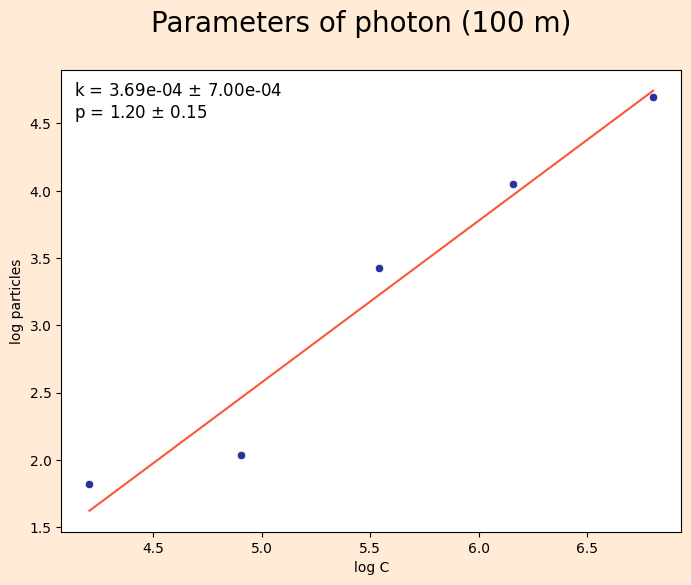

In [17]:
from scipy.optimize import curve_fit

# Fit do fóton

C = [1.611e+04, 8.043e+04, 3.477e+05, 1.436e+06, 6.356e+06]
particles = [65.89049658091947, 108.22319679526278, 2675.802030029076, 11145.315087234694, 49589.05153473209]

E = [1E15, 3.16E15, 1E16, 3.16E16, 1E17]

logC = np.log10(C)
logparticles = np.log10(particles)
#logE = np.log10(E)


fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
fig.suptitle('Parameters of photon (100 m)', size = 20)
#fig.tight_layout()


#ax.set_title('log particles x log C', size = 15)
ax.set_xlabel('log C')
ax.set_ylabel('log particles')
ax.set_facecolor('white')


#Fit
def power(x, k, p):
    return np.log10(k*x**p)

initial_guess = [1,1]

coefficients_photon, cov = curve_fit(power, C, np.log10(particles), p0=initial_guess)

inc = np.sqrt(np.diag(cov))
print(np.sqrt(np.diag(cov)))

print(power(C,*coefficients_photon))

ax.plot(logC, power(C,*coefficients_photon), color = '#F95738')
sns.scatterplot(x = logC, y = logparticles, color = '#29339B', ax = ax)

ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'
          .format(coefficients_photon[0],inc[0],coefficients_photon[1],inc[1]),
          title_fontsize = 12,facecolor = 'white', frameon = False)

[4.68049228e-16 1.79107828e-01]
[ 7.14873854  7.92486291  8.70195933  9.4780837  10.25518012]


C:\Users\Lucas\AppData\Local\Temp\ipykernel_1116\1788472954.py:23: RuntimeWarning: invalid value encountered in log10
  return np.log10(k*x**p)
C:\Users\Lucas\AppData\Local\Temp\ipykernel_1116\1788472954.py:37: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'


logC,logE_S,logE_R,error (%)
f64,f64,f64,f64
7.315973,15.0,15.107669,0.717795
7.53147,15.499687,15.246412,1.634068
8.924604,16.0,16.143344,0.895899
9.544242,16.499687,16.542281,0.258153
10.192536,17.0,16.959668,0.237247


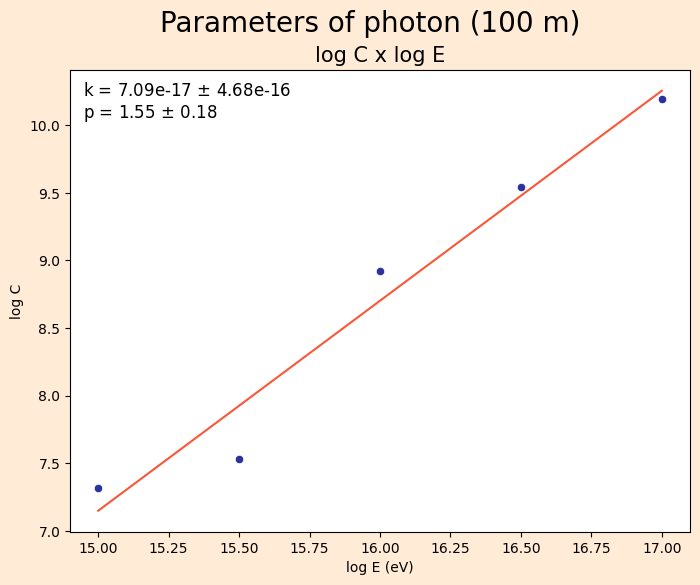

In [18]:
# Fit do fóton

C = [2.070011e+07, 3.399932e+07, 840628E3, 3501404E3, 1.557886e+10]
E = [1E15, 3.16E15, 1E16, 3.16E16, 1E17]

logC = np.log10(C)
logE = np.log10(E)


fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
fig.suptitle('Parameters of photon (100 m)', size = 20)
#fig.tight_layout()


ax.set_title('log C x log E', size = 15)
ax.set_xlabel('log E (eV)')
ax.set_ylabel('log C')
ax.set_facecolor('white')


#Fit
def power(x, k, p):
    return np.log10(k*x**p)

initial_guess = [1,1]

coefficients_photon, cov = curve_fit(power, E, np.log10(C), p0=initial_guess)

inc = np.sqrt(np.diag(cov))
print(np.sqrt(np.diag(cov)))

print(power(E,*coefficients_photon))

ax.plot(logE, power(E,*coefficients_photon), color = '#F95738')
sns.scatterplot(x = logE, y = logC, color = '#29339B', ax = ax)

ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'
          .format(coefficients_photon[0],inc[0],coefficients_photon[1],inc[1]),
          title_fontsize = 12,facecolor = 'white', frameon = False)


logE_0_array = ((np.log10(C/coefficients_photon[0]))/coefficients_photon[1])

logE_0 = logE_0_array.tolist()

data = {
    'logC':logC,
    'logE_S':logE,
    'logE_R':logE_0
}

df = pl.DataFrame(data)

df = df.with_columns(
        abs((((pl.col('logE_R')-pl.col('logE_S'))/pl.col('logE_S'))*100)).alias('error (%)')
)
df

In [19]:
# Leitura do arquivo

caminho_arquivo = 'tratados_10x10det/photon/photon3.16E16_array'

df = pl.read_csv(caminho_arquivo, has_header= False).filter(pl.col('column_1').str.contains('TRIG'))

df = df.with_columns(pl.col("column_1").str.split(" ").alias("split_column"))
df = df.with_columns(pl.col("split_column").list.get(0).alias("TRIG"))
df = df.with_columns(pl.col("split_column").list.get(1).cast(pl.Int64).alias("positrons"))
df = df.with_columns(pl.col("split_column").list.get(2).cast(pl.Int64).alias("electrons"))
df = df.with_columns(pl.col("split_column").list.get(3).cast(pl.Int64).alias("muons_plus"))
df = df.with_columns(pl.col("split_column").list.get(4).cast(pl.Int64).alias("muons_minus"))
df = df.with_columns(
    (pl.col("positrons") + pl.col("electrons") + pl.col("muons_plus") + pl.col("muons_minus")).alias("total_particles")
)

df

column_1,split_column,TRIG,positrons,electrons,muons_plus,muons_minus,total_particles
str,list[str],str,i64,i64,i64,i64,i64
"""TRIG1 0 0 0 0""","[""TRIG1"", ""0"", … ""0""]","""TRIG1""",0,0,0,0,0
"""TRIG2 0 0 0 0""","[""TRIG2"", ""0"", … ""0""]","""TRIG2""",0,0,0,0,0
"""TRIG3 0 0 0 0""","[""TRIG3"", ""0"", … ""0""]","""TRIG3""",0,0,0,0,0
"""TRIG4 0 0 0 0""","[""TRIG4"", ""0"", … ""0""]","""TRIG4""",0,0,0,0,0
"""TRIG5 0 0 0 0""","[""TRIG5"", ""0"", … ""0""]","""TRIG5""",0,0,0,0,0
…,…,…,…,…,…,…,…
"""TRIG96 0 0 0 0""","[""TRIG96"", ""0"", … ""0""]","""TRIG96""",0,0,0,0,0
"""TRIG97 0 0 0 0""","[""TRIG97"", ""0"", … ""0""]","""TRIG97""",0,0,0,0,0
"""TRIG98 0 0 0 0""","[""TRIG98"", ""0"", … ""0""]","""TRIG98""",0,0,0,0,0


In [20]:
import re
def formatar_string(s):

    nome_arquivo = s.split('/')[-1]
   
    match = re.match(r'([a-zA-Z]+)([0-9]+(?:\.[0-9]+)?[Ee][0-9]+)', nome_arquivo)

    if match:
        
        palavra = match.group(1).capitalize()
        numero = match.group(2)

        return f'{palavra} {numero}'
    else:
        return nome_arquivo

name = formatar_string(caminho_arquivo)
name

'Photon 3.16E16'

In [21]:
# Posição dos tanques

numDetectors = 100
gridSize = 10
spacing = 10
area = 1.0

x_det = np.zeros(numDetectors)
y_det = np.zeros(numDetectors)
areas = np.full(numDetectors, area)

index = 0
halfGridSize = gridSize // 2

for i in range(gridSize):
    for j in range(gridSize):
        x_det[index] = (j - halfGridSize + 0.5) * spacing
        y_det[index] = (i - halfGridSize + 0.5) * spacing
        areas[index] = area
        index += 1

#print("x_det:", x_det)
#print("y_det:", y_det)
#print("areas:", areas)

In [22]:
from scipy.spatial import KDTree

df2 = df.group_by('TRIG').agg(pl.col('total_particles')).sort(
    pl.col('TRIG').str.extract(r"TRIG([0-9]*)", 1).cast(int)
)

# Método KDTree 
positions = np.column_stack((x_det, y_det))
tree = KDTree(positions)
d_max = 15  # Distância máxima para considerar como próximos

# Validar simulações com triangulação
num_simulations = len(df2["total_particles"][0])

valid_simulations = []

for sim_idx in range(num_simulations):
    detections = np.array([df2["total_particles"][i][sim_idx] > 0 for i in range(100)])  

    detected_indices = np.where(detections)[0]
    if len(detected_indices) < 3:
        continue
    
    neighbors = []
    for tank in detected_indices:
        neighbors.append(set(tree.query_ball_point(positions[tank], d_max)))
    
    valid = False
    n = len(detected_indices)
    for i in range(n):
        tank_i = detected_indices[i]
        for j in range(i + 1, n):
            tank_j = detected_indices[j]
            if tank_j not in neighbors[i]:  
                continue
            for k in range(j + 1, n):
                tank_k = detected_indices[k]
                if tank_k in neighbors[i] and tank_k in neighbors[j]:
                    valid = True
                    break
            if valid:
                break
        if valid:
            break
    
    if valid:
        valid_simulations.append(sim_idx)


# Atualizar o dataframe
triangulation_particles = [
    [particles[i] for i in valid_simulations] for particles in df2["total_particles"]
]

triangulation_particles = df2.with_columns(
    pl.Series("triangulation_particles", triangulation_particles)
)

print(f"Simulações válidas: {len(valid_simulations)}")
triangulation_particles

Simulações válidas: 515


TRIG,total_particles,triangulation_particles
str,list[i64],list[i64]
"""TRIG1""","[0, 393, … 510]","[393, 0, … 510]"
"""TRIG2""","[0, 0, … 915]","[0, 0, … 915]"
"""TRIG3""","[0, 0, … 0]","[0, 0, … 0]"
"""TRIG4""","[0, 0, … 0]","[0, 0, … 0]"
"""TRIG5""","[0, 888, … 0]","[888, 749, … 0]"
…,…,…
"""TRIG96""","[543, 0, … 0]","[0, 0, … 0]"
"""TRIG97""","[0, 0, … 0]","[0, 0, … 0]"
"""TRIG98""","[0, 0, … 0]","[0, 622, … 0]"


In [23]:
triangulation_particles = triangulation_particles.with_columns(mean_particles = pl.col('triangulation_particles').list.mean())  
trigs = triangulation_particles['mean_particles'].to_list()
triangulation_particles

TRIG,total_particles,triangulation_particles,mean_particles
str,list[i64],list[i64],f64
"""TRIG1""","[0, 393, … 510]","[393, 0, … 510]",43.27767
"""TRIG2""","[0, 0, … 915]","[0, 0, … 915]",68.524272
"""TRIG3""","[0, 0, … 0]","[0, 0, … 0]",82.959223
"""TRIG4""","[0, 0, … 0]","[0, 0, … 0]",102.060194
"""TRIG5""","[0, 888, … 0]","[888, 749, … 0]",147.58835
…,…,…,…
"""TRIG96""","[543, 0, … 0]","[0, 0, … 0]",119.990291
"""TRIG97""","[0, 0, … 0]","[0, 0, … 0]",107.770874
"""TRIG98""","[0, 0, … 0]","[0, 622, … 0]",80.460194


Text(62.722222222222214, 0.5, 'y (m)')

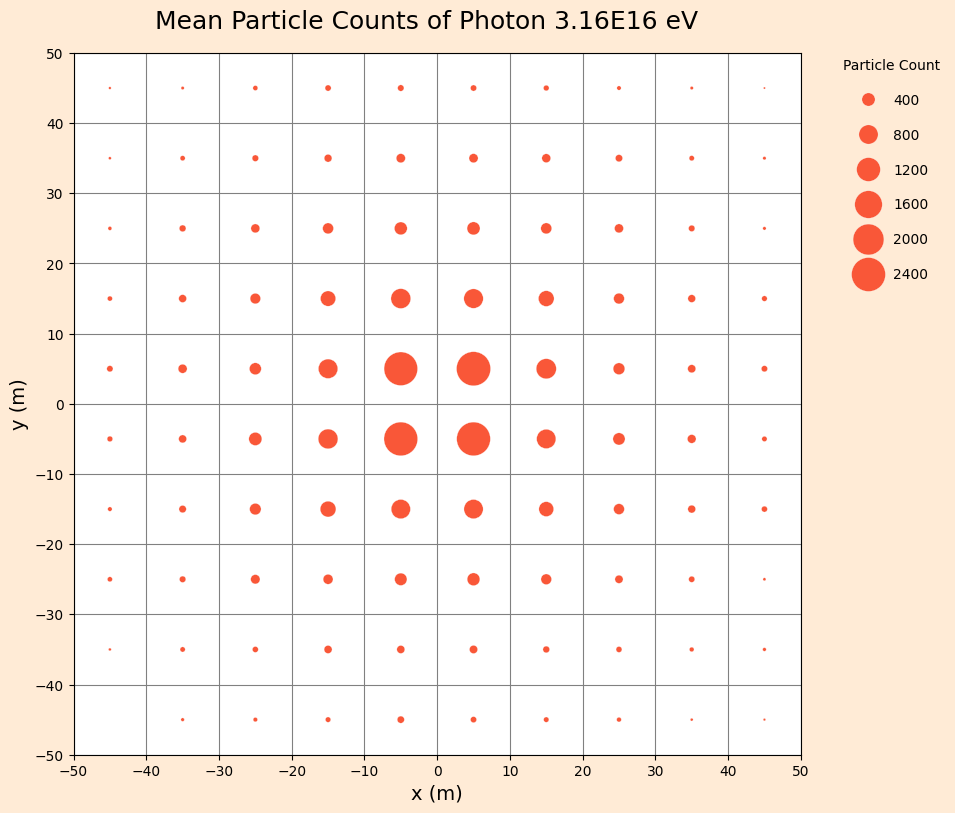

In [24]:
# Plot de partículas por tanque
fig, ax = plt.subplots(1, 1, figsize = (8, 8), facecolor = '#FFEBD6')
fig.suptitle('Mean Particle Counts of ' + str(name) + ' eV', size = 18)
fig.tight_layout()
ax.set_axisbelow(True)
ax.yaxis.grid(color='gray', linestyle='-')
ax.xaxis.grid(color='gray', linestyle='-')

scatter = sns.scatterplot(x = x_det, y = y_det, ax = ax, color = '#F95738', size=trigs, sizes=(0, 600), legend = 'brief')
handles, labels = scatter.get_legend_handles_labels()
for handle in handles:
    handle.set_color('#F95738')
ax.legend(handles=handles, labels=labels, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.,
           frameon=False, title='Particle Count', labelspacing = 1.5)

plt.xticks(ticks=[-50, -40, -30, -20, -10, 0, 10, 20, 30, 40, 50])
plt.yticks(ticks=[-50, -40, -30, -20, -10, 0, 10, 20, 30, 40, 50])
ax.set_xlabel('x (m)', size = 14)
ax.set_ylabel('y (m)', size = 14)


#plt.savefig('plots/' + name.split(' ')[0].lower() + '/counts_' + caminho_arquivo.split('/')[-1].split('_')[0] + '.png', bbox_inches = 'tight', dpi = 300)

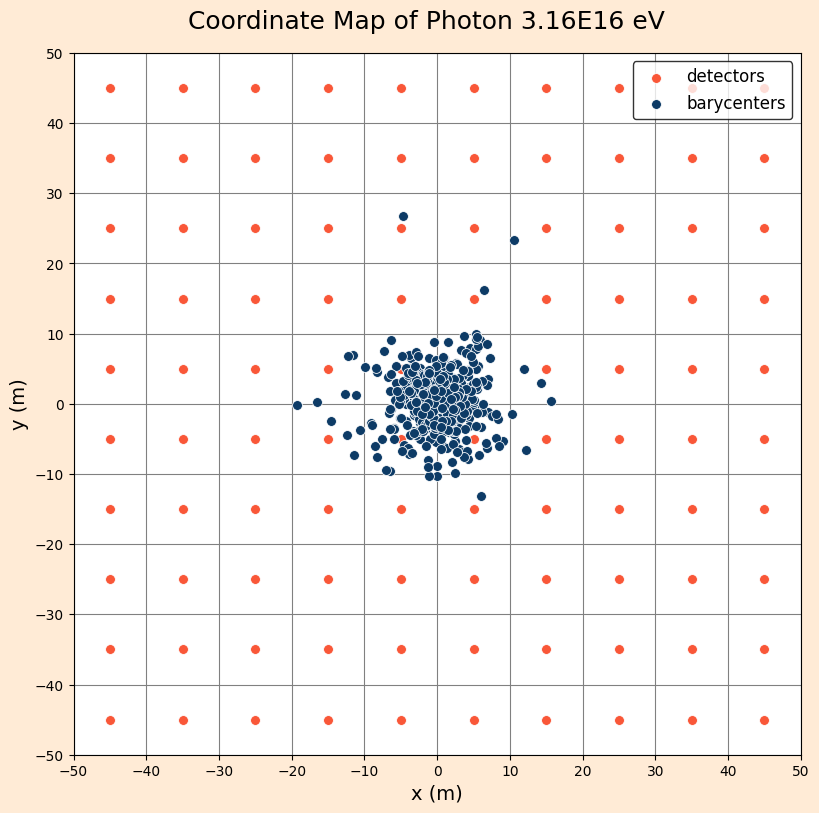

In [25]:
# Posição dos baricentros
x_b = [0] * len(valid_simulations)
y_b = [0] * len(valid_simulations)
rho = []

for i in range(len(valid_simulations)):
        numerator = 0
        numerator1 = 0
        denominator = 0
        for j in range(len(trigs)):
                numerator += (triangulation_particles['triangulation_particles'][j][i]*x_det[j])
                numerator1 += (triangulation_particles['triangulation_particles'][j][i]*y_det[j])
                denominator += (triangulation_particles['triangulation_particles'][j][i])
                rho.append((triangulation_particles['triangulation_particles'][j][i])/1)
                if denominator != 0: 
                    x_b[i] = numerator / denominator
                    y_b[i] = numerator1 / denominator
                else:
                    x_b[i] = 0 
                    y_b[i] = 0 

fig, ax = plt.subplots(1, 1, figsize = (8, 8), facecolor = '#FFEBD6')
fig.suptitle('Coordinate Map of ' + str(name) + ' eV', size = 18)
fig.tight_layout()
ax.set_axisbelow(True)
ax.yaxis.grid(color='gray', linestyle='-')
ax.xaxis.grid(color='gray', linestyle='-')

sns.scatterplot(x = x_det, y = y_det, ax = ax, color = '#F95738', s = 50)
sns.scatterplot(x = x_b, y = y_b, ax = ax, color = '#0D3B66',s = 50)

plt.xticks(ticks=[-50, -40, -30, -20, -10, 0, 10, 20, 30, 40, 50])
plt.yticks(ticks=[-50, -40, -30, -20, -10, 0, 10, 20, 30, 40, 50])
ax.set_xlabel('x (m)', size = 14)
ax.set_ylabel('y (m)', size = 14)


ax.legend(['detectors', 'barycenters'], edgecolor = 'black', fontsize = 12, loc = 1)

#plt.savefig('plots/' + name.split(' ')[0].lower() + '/map_' + caminho_arquivo.split('/')[-1].split('_')[0] + '.png',bbox_inches = 'tight', dpi = 300)

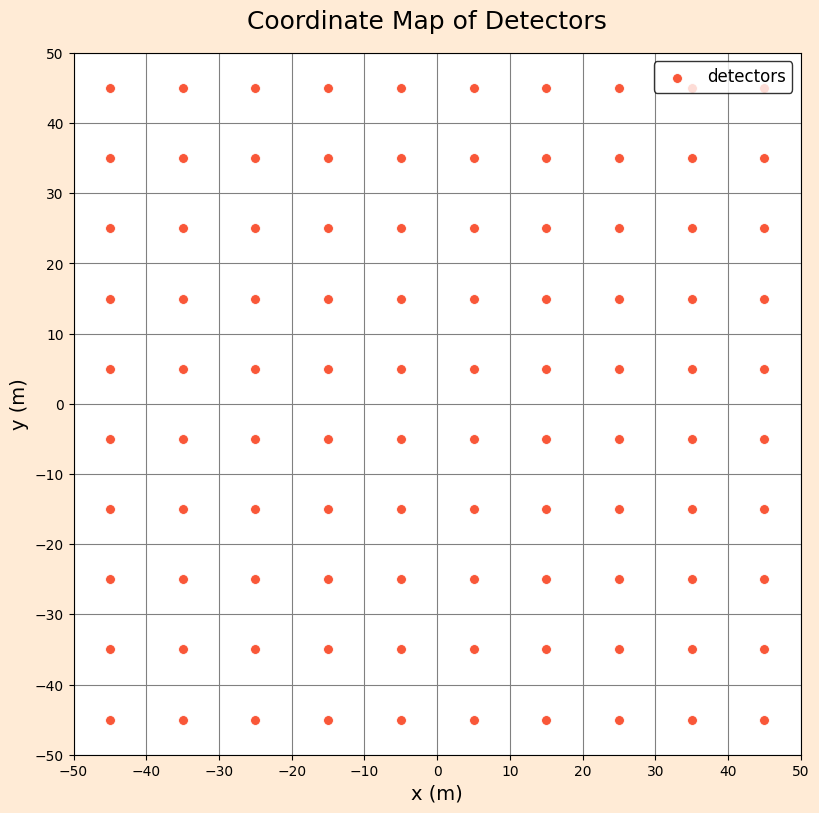

In [26]:
fig, ax = plt.subplots(1, 1, figsize = (8, 8), facecolor = '#FFEBD6')
fig.suptitle('Coordinate Map of Detectors', size = 18)
fig.tight_layout()
ax.set_axisbelow(True)
ax.yaxis.grid(color='gray', linestyle='-')
ax.xaxis.grid(color='gray', linestyle='-')

sns.scatterplot(x = x_det, y = y_det, ax = ax, color = '#F95738', s = 50)

plt.xticks(ticks=[-50, -40, -30, -20, -10, 0, 10, 20, 30, 40, 50])
plt.yticks(ticks=[-50, -40, -30, -20, -10, 0, 10, 20, 30, 40, 50])
ax.set_xlabel('x (m)', size = 14)
ax.set_ylabel('y (m)', size = 14)


ax.legend(['detectors'], edgecolor = 'black', fontsize = 12, loc = 1)

In [27]:
r_b = [] 

# Estruturação da lista rho para 100 tanques
rho_reshaped = np.array(rho).reshape(len(x_b), 100)


for i in range(len(valid_simulations)):
    #aux = ((x_det[i]-x_b[i])**2 + (y_det[i]-y_b[i])**2)**0.5
    aux = x_b[i]** 2 + y_b[i]**2
    r_b.append(aux)

data = {
    'x_b':x_b,
    'y_b':y_b,
    'r_b':r_b
}

for i in range(100):
    data[f'rho_{i+1}'] = rho_reshaped[:, i].tolist()

df = pl.DataFrame(data, strict=False)

rho_cols = [pl.col(f'rho_{i+1}') for i in range(100)]

df = df.with_columns(
    rho_total=pl.sum_horizontal(rho_cols)        
)

df = df.with_columns(
    particles_total=pl.col('rho_total') * 1
)

df = df.with_columns(
    C=(pl.col("particles_total") / coefficients_photon[0]).pow(1 / coefficients_photon[1])
)

distance_bary = []
for i in range(100):
    x = x_det[i]
    y = y_det[i]
    expr = ((pl.col("x_b") - x)**2 + (pl.col("y_b") - y)**2).sqrt().alias(f"r{i+1}_b")
    distance_bary.append(expr)

df = df.with_columns(distance_bary)

# Reordenar colunas
df = df.select([
    'x_b', 
    'y_b', 
    'r_b', 
    #'rho_total', 
    'particles_total', 
    'C',
    *[f'r{i+1}_b' for i in range(100)],
    *[f'rho_{i+1}' for i in range(100)]
])

df

x_b,y_b,r_b,particles_total,C,r1_b,r2_b,r3_b,r4_b,r5_b,r6_b,r7_b,r8_b,r9_b,r10_b,r11_b,r12_b,r13_b,r14_b,r15_b,r16_b,r17_b,r18_b,r19_b,r20_b,r21_b,r22_b,r23_b,r24_b,r25_b,r26_b,r27_b,r28_b,r29_b,r30_b,r31_b,r32_b,…,rho_64,rho_65,rho_66,rho_67,rho_68,rho_69,rho_70,rho_71,rho_72,rho_73,rho_74,rho_75,rho_76,rho_77,rho_78,rho_79,rho_80,rho_81,rho_82,rho_83,rho_84,rho_85,rho_86,rho_87,rho_88,rho_89,rho_90,rho_91,rho_92,rho_93,rho_94,rho_95,rho_96,rho_97,rho_98,rho_99,rho_100
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
1.658392,0.512676,3.013099,39879.0,2.2885e13,65.179822,58.440066,52.745365,48.46551,45.99715,45.635184,47.427863,51.149138,56.418672,62.848219,58.635788,51.039081,44.40518,39.225657,36.131487,35.669546,37.936113,42.496833,48.711528,56.032537,53.178023,44.662448,36.89941,30.469635,26.36723,25.730584,28.790539,34.57929,41.982847,50.293058,49.16959,39.805537,…,1355.0,0.0,0.0,0.0,1382.0,738.0,490.0,0.0,0.0,0.0,510.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1161.0,1520.0,0.0,0.0,720.0,0.0,343.0,0.0,0.0,0.0,0.0,0.0,0.0,718.0,0.0
0.552789,-0.783816,0.919942,40558.0,2.3135e13,63.483285,56.736864,51.068738,46.871742,44.563487,44.439269,46.516587,50.524619,56.050703,62.694701,56.971956,49.343166,42.70471,37.585057,34.663824,34.503985,37.141206,42.052508,48.552627,56.091906,51.589535,43.016559,35.204667,28.780424,24.844658,24.621155,28.198324,34.410605,42.10741,50.615987,47.71956,38.289694,…,0.0,892.0,1233.0,120.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,773.0,1237.0,630.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,577.0,0.0,0.0,0.0,0.0,809.0,0.0,0.0,0.0,0.0,622.0,0.0,0.0
6.939772,3.522196,60.566297,12187.0,1.0668e13,71.078431,64.135388,58.090899,53.251827,49.969607,48.560953,49.1871,51.774273,56.051582,61.668342,64.666061,56.946502,50.041069,44.331853,40.330109,38.571003,39.356408,42.545639,47.658535,54.152937,59.255848,50.719425,42.821311,35.984292,30.920443,28.588081,29.639213,33.759258,40.011149,47.561504,55.143555,45.84775,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,920.0,696.0,0.0,1550.0,0.0,0.0,1120.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,419.0,704.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0.687888,-1.245539,2.024556,39505.0,2.2746e13,63.260066,56.46307,50.737762,46.481854,44.122613,43.966433,46.035741,50.055287,55.603722,62.27372,56.804461,49.122184,42.417346,37.221949,34.230334,34.028782,36.663336,41.598587,48.131951,55.703922,51.494247,42.870733,34.987741,28.467249,24.425939,24.142675,27.732851,33.990488,41.732427,50.277607,47.713397,38.246706,…,514.0,455.0,646.0,0.0,0.0,858.0,0.0,422.0,0.0,512.0,0.0,0.0,730.0,421.0,872.0,0.0,0.0,0.0,0.0,538.0,506.0,0.0,0.0,0.0,0.0,486.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1.09927,1.202014,2.653232,48373.0,2.5914e13,65.266904,58.632614,53.064093,48.926604,46.602866,46.366386,48.247864,52.017987,57.305196,63.733038,58.615088,51.12478,44.629113,39.620352,36.712217,36.411557,38.779067,43.380072,49.596827,56.902196,53.025355,44.606085,36.982664,30.752756,26.902539,26.490776,29.661015,35.465341,42.846295,51.125528,48.863565,39.568454,…,1185.0,544.0,1456.0,1696.0,0.0,1429.0,0.0,604.0,396.0,0.0,1094.0,0.0,0.0,1079.0,1327.0,0.0,368.0,0.0,0.0,474.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,472.0,0.0,0.0,829.0,0.0,0.0,0.0,0.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
-1.70411,-0.431727,3.090378,69083.0,3.2597e13,62.13586,55.63225,50.289457,46.509264,44.689975,45.06968,47.59578,51.956139,57.736666,64.556989,55.403065,47.995644,41.685297,37.037092,34.72504,35.212364,38.392613,43.681517,50.419809,58.105416,49.780861,41.378936,33.857031,27.935296,24.788363,25.466549,29.709044,36.286492,44.167768,52.771904,45.681164,36.343512,…,0.0,0.0,5499.0,1958.0,493.0,502.0,56

In [28]:
df.select(pl.col('particles_total')).mean()

particles_total
f64
31602.174757


[1.2284561e-17 1.0957023e-01]
[2.47679766 3.14284354 3.80972362 4.47576951 5.14264958]


C:\Users\Lucas\AppData\Local\Temp\ipykernel_1116\3254045624.py:23: RuntimeWarning: invalid value encountered in log10
  return np.log10(k*x**p)
C:\Users\Lucas\AppData\Local\Temp\ipykernel_1116\3254045624.py:37: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'


logC,logE_S,logE_R,error (%)
f64,f64,f64,f64
2.421733,15.0,14.958689,0.27541
3.041774,15.499687,15.423862,0.489205
4.059508,16.0,16.187396,1.171224
4.499717,16.499687,16.517653,0.108887
5.025052,17.0,16.911775,0.518973


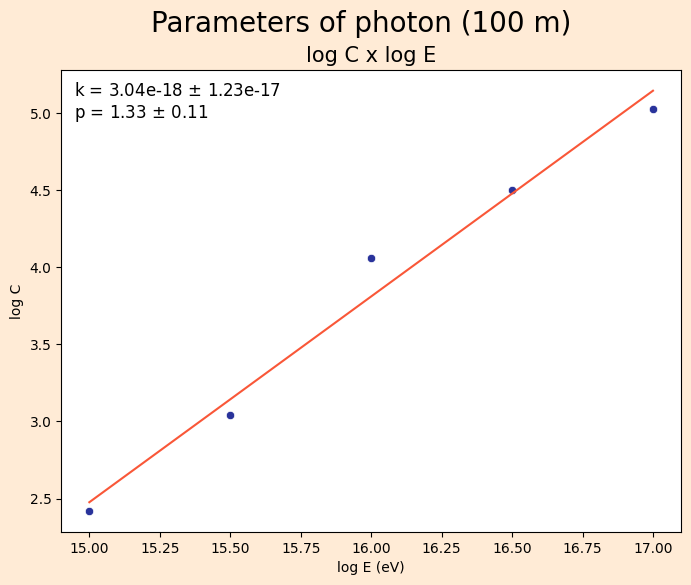

In [29]:
# Fit do fóton

C = [264.078203, 1100.966667, 11468.548872, 31602.174757, 105937.997234]
E = [1E15, 3.16E15, 1E16, 3.16E16, 1E17]

logC = np.log10(C)
logE = np.log10(E)


fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
fig.suptitle('Parameters of photon (100 m)', size = 20)
#fig.tight_layout()


ax.set_title('log C x log E', size = 15)
ax.set_xlabel('log E (eV)')
ax.set_ylabel('log C')
ax.set_facecolor('white')


#Fit
def power(x, k, p):
    return np.log10(k*x**p)

initial_guess = [1,1]

coefficients_photon, cov = curve_fit(power, E, np.log10(C), p0=initial_guess)

inc = np.sqrt(np.diag(cov))
print(np.sqrt(np.diag(cov)))

print(power(E,*coefficients_photon))

ax.plot(logE, power(E,*coefficients_photon), color = '#F95738')
sns.scatterplot(x = logE, y = logC, color = '#29339B', ax = ax)

ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'
          .format(coefficients_photon[0],inc[0],coefficients_photon[1],inc[1]),
          title_fontsize = 12,facecolor = 'white', frameon = False)


logE_0_array = ((np.log10(C/coefficients_photon[0]))/coefficients_photon[1])

logE_0 = logE_0_array.tolist()

data = {
    'logC':logC,
    'logE_S':logE,
    'logE_R':logE_0
}

df = pl.DataFrame(data)

df = df.with_columns(
        abs((((pl.col('logE_R')-pl.col('logE_S'))/pl.col('logE_S'))*100)).alias('error (%)')
)
df

In [30]:
# Modelagem NKG
def model(r, C, a, b):
    r0 = 78
    return C/(r0**2)*(r/r0)**(-a)*(1+r/r0)**(-b)


parameters = []
uncertainties = []
r_squared_list = []
rmse_list = []

x_cols = [f"r{i+1}_b" for i in range(100)]  
y_cols = [f"rho_{i+1}" for i in range(100)] 

x = df.select(x_cols).to_numpy()
y = df.select(y_cols).to_numpy()

#for i in range(len(x)):
#    print(f"Linha {i}: x = {x[i]}, y = {y[i]}")

for i in range(len(x)):
    r = x[i].flatten()  
    rho = y[i].flatten()
    C_fixed = df['C'][i]

    try:
        
        def current_model(r, a, b):
            return model(r, C_fixed, a, b)
        
        popt, pcov = curve_fit(current_model, r, rho, p0= [0.7, 3] , bounds= ([0, 2.5], [1.5, 4.0]))
        perr = np.sqrt(np.diag(pcov))

        # Cálculo das métricas
        y_pred = current_model(r, *popt)

        # R²
        ss_res = np.sum((rho - y_pred)**2)
        ss_tot = np.sum((rho - np.mean(rho))**2)
        r_sq = 1 - (ss_res/ss_tot) if ss_tot != 0 else np.nan

        # RMSE
        rmse = np.sqrt(np.mean((rho - y_pred)**2))

        parameters.append([C_fixed,popt[0], popt[1]])
        uncertainties.append([0, perr[0], perr[1]])
        #parameters.append(popt)
        #uncertainties.append(perr)
        r_squared_list.append(r_sq)
        rmse_list.append(rmse)
    except RuntimeError:
        parameters.append([np.nan, np.nan])
        uncertainties.append([np.nan, np.nan])
        r_squared_list.append(np.nan)
        rmse_list.append(np.nan)


# Cria DataFrame com todos os parâmetros
parameters_df = pl.DataFrame({
    'C': [p[0] for p in parameters],
    'a': [p[1] for p in parameters],
    'b': [p[2] for p in parameters],
    'C_err': [e[0] for e in uncertainties],
    'a_err': [e[1] for e in uncertainties],
    'b_err': [e[2] for e in uncertainties],
    'R_2': r_squared_list,
    'RMSE': rmse_list
})

# Filtra valores válidos para estatísticas
valid = parameters_df.filter(
    pl.all_horizontal(
        pl.col('C').is_not_nan(),
        pl.col('a').is_not_nan(),
        pl.col('b').is_not_nan()
    )
)
print(parameters_df)

print("\nEstatísticas dos parâmetros:")
print(f"C: Média = {valid['C'].mean():.2e} ± {valid['C'].std():.2e}")
print(f"a: Média = {valid['a'].mean():.2f} ± {valid['a'].std():.2f}")
print(f"b: Média = {valid['b'].mean():.2f} ± {valid['b'].std():.2f}")
print(f"R² Médio = {valid['R_2'].mean():.3f} ± {valid['R_2'].std():.3f}")
print(f"RMSE Médio = {valid['RMSE'].mean():.3e} ± {valid['RMSE'].std():.3e}")

ColumnNotFoundError: r1_b

Resolved plan until failure:

	---> FAILED HERE RESOLVING 'select' <---
DF ["logC", "logE_S", "logE_R", "error (%)"]; PROJECT */4 COLUMNS

In [ ]:
fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
plt.title('One EAS for ' + str(name) + ' eV', size = 20)
#fig.tight_layout()


#ax.set_title('log C x log E', size = 15)
ax.set_xlabel('Distance (m)', size = 14)
ax.set_ylabel('Density (N/m$^2$)', size = 14)
ax.set_facecolor('white')

i = 200

C = parameters_df['C'][i]
a = parameters_df['a'][i]
b = parameters_df['b'][i]
C_err = parameters_df['C_err'][i]
b_err = parameters_df['b_err'][i]

r_smooth = np.linspace(min(x[i]), max(x[i]), 300)
rho_fit = model(r_smooth, C, a, b)

sns.lineplot(x=r_smooth, y=rho_fit, color='#FF6B6B', ax=ax, label='NKG fit')

sns.scatterplot(x = x[i], y = y[i], color = '#29339B', ax = ax, label = 'detectors')

textstr = f'C = {C:.2e} $\pm$ {C_err:.2e}\na = {a:.2f}\nb = {b:.2f} $\pm$ {b_err:.2f}\nR² = {parameters_df["R_2"][i]:.3f}'

ax.text(0.95, 0.95, textstr, transform=ax.transAxes,
        verticalalignment='top', horizontalalignment='right',
        fontsize = 12
        )

ax.legend(
    loc='lower left',
    fontsize=11,
    frameon=True,
    facecolor='white',
)

plt.show()


In [ ]:
fig, ax = plt.subplots(figsize=(8, 6), facecolor='#FFEBD6')
plt.title(f'EAS Fits for {name} eV', size=20)
ax.set_xlabel('Distance (m)', size=14)
ax.set_ylabel('Density (N/m$^2$)', size=14)
ax.set_facecolor('white')
ax.set_yscale('log')

for i, row in enumerate(parameters_df.iter_rows(named=True)):  
    C = row['C']
    a = row['a']
    b = row['b']
    
    # Gera pontos suaves para a curva
    r_smooth = np.linspace(min(x[i]), max(x[i]), 300)
    rho_fit = model(r_smooth, C, a, b)
    
    # Plota a curva de ajuste
    label_fit = 'NKG fit' if i == 0 else None
    sns.lineplot(x=r_smooth, y=rho_fit, color='#FF6B6B', ax=ax, 
                 label=label_fit, alpha = 0.8)
    
    # Plota os pontos dos detectores
    label_scatter = 'detectors' if i == 0 else None
    sns.scatterplot(x=x[i], y=y[i], color='#29339B', ax=ax, 
                    label=label_scatter)

ax.legend(
    loc='upper right',
    fontsize=11,
    frameon=True,
    facecolor='white',
)

plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6), facecolor='#FFEBD6')
plt.title(f'EAS Fits for {name} eV', size=20)
ax.set_xlabel('Distance (m)', size=14)
ax.set_ylabel('Density (N/m$^2$)', size=14)
ax.set_facecolor('white')
#ax.set_yscale('log')

for i, row in enumerate(parameters_df.iter_rows(named=True)):  
    C = row['C']
    a = row['a']
    b = row['b']
    
    # Gera pontos suaves para a curva
    r_smooth = np.linspace(min(x[i]), max(x[i]), 300)
    rho_fit = model(r_smooth, C, a, b)
    
    # Plota a curva de ajuste
    label_fit = 'NKG fit' if i == 0 else None
    sns.lineplot(x=r_smooth, y=rho_fit, color='#FF6B6B', ax=ax, 
                 label=label_fit, alpha = 0.8)
    
    # Plota os pontos dos detectores
    label_scatter = 'detectors' if i == 0 else None
    sns.scatterplot(x=x[i], y=y[i], color='#29339B', ax=ax, 
                    label=label_scatter)

ax.legend(
    loc='upper right',
    fontsize=11,
    frameon=True,
    facecolor='white',
)

plt.show()

In [ ]:
# Fit do fóton

C = [1.611e+04, 8.043e+04, 3.477e+05, 1.436e+06, 6.356e+06]
E = [1E15, 3.16E15, 1E16, 3.16E16, 1E17]

logC = np.log10(C)
logE = np.log10(E)


fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
fig.suptitle('Parameters of photon (100 m)', size = 20)
#fig.tight_layout()


ax.set_title('log C x log E', size = 15)
ax.set_xlabel('log E (eV)')
ax.set_ylabel('log C')
ax.set_facecolor('white')


#Fit
def power(x, k, p):
    return np.log10(k*x**p)

initial_guess = [1,1]

coefficients_photon, cov = curve_fit(power, E, np.log10(C), p0=initial_guess)

inc = np.sqrt(np.diag(cov))
print(np.sqrt(np.diag(cov)))

print(power(E,*coefficients_photon))

ax.plot(logE, power(E,*coefficients_photon), color = '#F95738')
sns.scatterplot(x = logE, y = logC, color = '#29339B', ax = ax)

ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'
          .format(coefficients_photon[0],inc[0],coefficients_photon[1],inc[1]),
          title_fontsize = 12,facecolor = 'white', frameon = False)


logE_0_array = ((np.log10(C/coefficients_photon[0]))/coefficients_photon[1])

logE_0 = logE_0_array.tolist()

data = {
    'logC':logC,
    'logE_S':logE,
    'logE_R':logE_0
}

df = pl.DataFrame(data)

df = df.with_columns(
        abs((((pl.col('logE_R')-pl.col('logE_S'))/pl.col('logE_S'))*100)).alias('error (%)')
)
df

In [ ]:
k_photon = coefficients_photon[0] #- inc[0]
p_photon = coefficients_photon[1] #- inc[1]
c_photon = parameters_df['C'] #- parameters_df['C_err']

E_photon = []
E_real = float(name.split(' ')[1])

erro_relativo = []
erro_absoluto = []

for i in range(len(c_photon)):
    E = (c_photon[i] / k_photon) ** (1 / p_photon)
    E_photon.append(E)
    
    # Calcular erro absoluto
    erro_abs = abs(E - E_real)
    erro_absoluto.append(erro_abs)
    
    # Calcular erro relativo (em porcentagem)
    erro_rel = (erro_abs / E_real) * 100
    erro_relativo.append(erro_rel)

data = {
    'E':E_photon,
    'Relative_error':erro_relativo,
    'Absolute_error':erro_absoluto
}

df3 = pl.DataFrame(data)
df3

In [ ]:
fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
plt.hist(erro_relativo, color='#29339B', bins= 40, edgecolor = 'white')
plt.ylabel('Simulations')
plt.xlabel('Relative Error (%)')
plt.title('Relative Error for ' + str(name) + ' eV', size = 18)
#plt.grid(True)

# Calcula a média e o desvio padrão dos dados
mean = df3['Relative_error'].mean()
std = df3['Relative_error'].std()

# Determina os limites de 2 sigma
#lower_bound = mean - 2 * std
upper_bound = mean + 2 * std


# Adiciona linhas verticais para os limites de 2 sigma
#ax.axvline(lower_bound, color='#548C2F', linestyle='--', linewidth=2, label=f'Lower Bound (-2σ): {lower_bound:.2f}')
ax.axvline(upper_bound, color='#27213C', linestyle='--', linewidth=2, label=f'Upper Bound (+2σ): {upper_bound:.2f}%')
ax.axvline(mean, color='#F95738', linestyle='-', linewidth=2, label=f'Mean: {mean:.2f}%')

# Personaliza o eixo e a legenda
ax.set_xlabel('Relative error (%)', size=14)
ax.set_ylabel('Simulations', size=14)
ax.legend(loc='upper right', fontsize=12)

#plt.savefig('plots/' + name.split(' ')[0].lower() +'/energy_'+ caminho_arquivo.split('/')[-1] + '_array.png',bbox_inches = 'tight')